In [1]:
import matplotlib.pyplot as plt
import numpy as np

from astropy.visualization import time_support
from astropy.time import Time
import astropy.units as u

from sunpy import timeseries as ts
from sunpy.net import Fido
from sunpy.net import attrs as a

from stixpy.net.client import STIXClient
from stixpy.timeseries import quicklook 
from stixpy.product import Product

import datetime as dt
from sunpy.time import parse_time
from sunpy.time import TimeRange

import pandas as pd

from scipy.signal import find_peaks, savgol_filter

from matplotlib import dates

In [279]:
flares = pd.read_csv("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/data/STIX_flarelist_w_locations_20210214_20260228_version1_python.csv")
flarelist = flares.sort_values("25-50 keV", ascending=False).head(400)

In [940]:
flarelist.columns

Index(['start_UTC', 'end_UTC', 'peak_UTC', '4-10 keV', '10-15 keV',
       '15-25 keV', '25-50 keV', '50-84 keV', 'bkg 4-10 keV', 'bkg 10-15 keV',
       'bkg 15-25 keV', 'bkg 25-50 keV', 'bkg 50-84 keV',
       'bkg_baseline_4-10 keV', 'hpc_x_solo', 'hpc_y_solo', 'hpc_x_earth',
       'hpc_y_earth', 'visible_from_earth', 'hgs_lon', 'hgs_lat', 'hgc_lon',
       'hgc_lat', 'solo_position_lat', 'solo_position_lon',
       'solo_position_AU_distance', 'EAR_TDEL', 'GOES_class_time_of_flare',
       'GOES_flux_time_of_flare', 'att_in', 'flare_id', 'sidelobes_ratio',
       'goes_estimated_min_class', 'goes_estimated_max_class',
       'goes_estimated_mean_class', 'goes_estimated_min_flux',
       'goes_estimated_max_flux', 'goes_estimated_mean_flux',
       'error_with_imaging', 'cpd_filename'],
      dtype='str')

In [280]:
energy_ranges = [(25.0*u.keV, 50*u.keV), (50.0*u.keV, 100*u.keV)]

In [281]:
def t(string):
    return parse_time(string).datetime

def get_energy_indices(qtable, ranges):
    energy_indices = []
    for e_min, e_max in ranges:
        start_index = np.where(qtable["e_low"] >= e_min)[0][0]
        end_index = np.where(qtable["e_high"] <= e_max)[0][-1]
        energy_indices.append([int(start_index), int(end_index)])
    return energy_indices
    
def get_stix_df(stix_sci, energy_ranges):
    
    energy_indices = get_energy_indices(stix_sci.energies, energy_ranges)
    counts, errors, times, timedeltas, energies = stix_sci.get_data(detector_indices=[[0, 31]],
                                                                    pixel_indices=[[0, 11]],
                                                                    energy_indices=energy_indices,)
    counts = counts.to(u.ct / u.s / u.keV)
    errors = errors.to(u.ct / u.s / u.keV)
    timedeltas = timedeltas.to(u.s)
    
    times = times
    
    energy_columns = [f"{e['e_low']}-{e['e_high']}" for e in energies]
    
    counts_reshaped = counts[:, 0, 0, :]
    
    counts_df = pd.DataFrame(counts_reshaped, index=times.datetime, columns=energy_columns)
    return counts_df

In [282]:
df_list=[]
indices=[]
no_file=[]
i=0
for ind in flarelist.index:
    sci_query = Fido.search(a.Time(flarelist['start_UTC'].loc[ind], 
                                   flarelist['end_UTC'].loc[ind]), 
                        a.Instrument.stix,
                        a.stix.DataType.sci,
                        a.stix.DataProduct.sci_xray_spec)
    sci_query['stix'].filter_for_latest_version()
    
    start = parse_time(flarelist['start_UTC'].loc[ind]).datetime
    end = parse_time(flarelist['end_UTC'].loc[ind]).datetime

    gotfile=False
    for n in range(len(sci_query[0])):
        if sci_query[0][n][0].datetime<=t(flarelist['start_UTC'].loc[ind])+dt.timedelta(minutes=5) and sci_query[0][n][1].datetime>=t(flarelist['end_UTC'].loc[ind])-dt.timedelta(minutes=5):
            sci_files = Fido.fetch(sci_query[0][n])
            sci_data = Product(sci_files)
        
            sci_df = get_stix_df(sci_data, energy_ranges)
            df_list.append(sci_df)
            indices.append(ind)
            gotfile=True
            break
            
    if not gotfile:
        no_file.append(i)
        df_list.append(np.nan)
        indices.append(np.nan)
    i+=1

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

...

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

In [283]:
flag2=[]
iloc=0
for df in df_list:
    if isinstance(df, pd.DataFrame):
        bigger=False
        counter=0
        df.index=t(df.index)
        for i in range(len(df['25.0 keV-50.0 keV'])):
            if df['50.0 keV-100.0 keV'].iloc[i]>df['25.0 keV-50.0 keV'].iloc[i]: 
                counter+=1
        if counter>0.25*len(df):
            flag2.append(True)
            bigger=True
        if not bigger:
            flag2.append(False)
    else:
        flag2.append(True)
    iloc+=1

In [284]:
checklist2 = list(np.where(np.array(flag2)==True)[0])

In [314]:
i=0
for df in df_list:
    if isinstance(df, pd.DataFrame):
        fig, ax = plt.subplots()
        ax.set_ylabel('ct/(keV s)')
        ax.set_title(f"{parse_time(flarelist['start_UTC'].iloc[i]).datetime.year}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.month}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.day} {parse_time(flarelist['start_UTC'].iloc[i]).datetime.hour}:{parse_time(flarelist['start_UTC'].iloc[i]).datetime.minute}")
        ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))
        
        ax.plot(df.index, df['25.0 keV-50.0 keV'])
        ax.plot(df.index, df['50.0 keV-100.0 keV'])
        
        if i in checklist2:
            plt.axhline(0.5*np.max(df['25.0 keV-50.0 keV']),0, 1, linestyle = 'dashed', color='red')
        fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/top_400/flare"+str(i)+".png", bbox_inches='tight')
    i+=1

plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_16436\712731746.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [285]:
df_list_refined=[]
i=0
for df in df_list:
    if i not in checklist2:
        df_list_refined.append(df)
    i+=1

indices_refined = []
i=0
for ind in indices:
    if i not in checklist2:
        indices_refined.append(ind)
    i+=1

In [286]:
resampled_df_list = []
i=0
for df in df_list_refined:
    #df = df.truncate(starts[i], starts[i]+dt.timedelta(seconds=max(durations)))
    resampled_df = df.resample('1s').mean()
    resampled_df['25.0 keV-50.0 keV'] = resampled_df['25.0 keV-50.0 keV'].interpolate('linear')
    resampled_df['50.0 keV-100.0 keV'] = resampled_df['50.0 keV-100.0 keV'].interpolate('linear')
    resampled_df_list.append(resampled_df)
    i+=1

In [287]:
flarelist_refined = flarelist.loc[indices_refined]

In [307]:
# df = df_list_refined[0]

# start = parse_time(flarelist['start_UTC'].iloc[0]).datetime - dt.timedelta(minutes=15)
# end = parse_time(flarelist['end_UTC'].iloc[0]).datetime  + dt.timedelta(minutes=15)

# flare_df = df.truncate(start, end)
# flare_df.index = parse_time(flare_df.index).datetime 

# peak = np.max(flare_df['25.0 keV-50.0 keV'])
# peak_loc = flare_df.index[flare_df['25.0 keV-50.0 keV'] == peak][0]

# start_df = flare_df[(flare_df['25.0 keV-50.0 keV'].diff()>0.05) & (flare_df.index<peak_loc)]

# start = flare_df.index.get_loc(flare_df.index[flare_df.index == start_df.index[0]][0])

In [20]:
start_df.index[0]

Timestamp('2024-05-14 16:28:40.121000')

In [806]:
df_list_extrafiltered = []
for df in resampled_df_list:
    df_filtered = df.copy()
    
    filtered_2550 = savgol_filter(df['25.0 keV-50.0 keV'], window_length = 75, polyorder=2)
    filtered_50100 = savgol_filter(df['50.0 keV-100.0 keV'], window_length = 75, polyorder=2)

    df_filtered['25.0 keV-50.0 keV'] = filtered_2550
    df_filtered['50.0 keV-100.0 keV'] = filtered_50100

    df_list_extrafiltered.append(df_filtered)

In [933]:
def flare_durations(list_of_flare_dfs, flare_list_locations):

    durations = []
    estimated_starts = []
    estimated_ends = []
    durations_50100 = []
    estimated_starts_50100 = []
    estimated_ends_50100 = []
    
    for ind, df in enumerate(list_of_flare_dfs):
    
        start = parse_time(flarelist['start_UTC'].loc[flare_list_locations[ind]]).datetime - dt.timedelta(minutes=20)
        end = parse_time(flarelist['end_UTC'].loc[flare_list_locations[ind]]).datetime  + dt.timedelta(minutes=20)
    
        flare_df = df.truncate(start, end)
        flare_df.index = parse_time(flare_df.index).datetime 

        peak = np.max(flare_df['25.0 keV-50.0 keV'])
        peak_loc = flare_df.index[flare_df['25.0 keV-50.0 keV'] == peak][0]
    
        start_df = flare_df[(flare_df['25.0 keV-50.0 keV'].diff()>0.2) & (flare_df.index<peak_loc)]

        found_start=False
        for time in start_df.index:
            start = flare_df.index.get_loc(flare_df.index[flare_df.index == time][0])
            points = flare_df['25.0 keV-50.0 keV'].iloc[start:start+20]
            if points.is_monotonic_increasing:
                estimated_start = time
                found_start=True
                break
        
        if not found_start:
            estimated_start=np.nan

        end_df = flare_df[(flare_df['25.0 keV-50.0 keV']<np.mean(df['25.0 keV-50.0 keV'])) & (flare_df.index>peak_loc)]
        if not end_df.empty:
            estimated_end = end_df.index[0]
        else:
            estimated_end = np.nan
    
        estimated_starts.append(estimated_start)
        estimated_ends.append(estimated_end)
        
        if (pd.notna(estimated_start)) & (pd.notna(estimated_end)):
            estimated_duration = (estimated_end - estimated_start).total_seconds()
            durations.append(estimated_duration)
        else:
            durations.append(np.nan)

        if (pd.notna(estimated_start)) & (pd.notna(estimated_end)):
            flare_df_50100 = flare_df.truncate(estimated_start, estimated_end)
    
            peak_50100 = np.max(flare_df_50100['50.0 keV-100.0 keV'])
            peak_loc_50100 = flare_df_50100.index[flare_df_50100['50.0 keV-100.0 keV'] == peak_50100][0]
    
            start_df_50100 = flare_df_50100[(flare_df_50100['50.0 keV-100.0 keV'].diff()>0.1) & (flare_df_50100.index<peak_loc_50100)]
    
            found_start_50100=False
            for time in start_df_50100.index:
                start = flare_df_50100.index.get_loc(flare_df_50100.index[flare_df_50100.index == time][0])
                points = flare_df_50100['50.0 keV-100.0 keV'].iloc[start:start+5]
                if points.is_monotonic_increasing:
                    estimated_start_50100 = time
                    found_start_50100=True
                    break
    
            if not found_start_50100:
                estimated_start_50100=np.nan
    
            end_df_50100 = flare_df_50100[(flare_df_50100['50.0 keV-100.0 keV']<2*np.mean(df['50.0 keV-100.0 keV'])) & (flare_df_50100.index>peak_loc_50100)]
            if not end_df_50100.empty:
                estimated_end_50100 = end_df_50100.index[0]
            else:
                estimated_end_50100 = np.nan
        
            estimated_starts_50100.append(estimated_start_50100)
            estimated_ends_50100.append(estimated_end_50100)
            
            if (pd.notna(estimated_start_50100)) & (pd.notna(estimated_end_50100)):
                estimated_duration_50100 = (estimated_end_50100 - estimated_start_50100).total_seconds()
                durations_50100.append(estimated_duration_50100)
            else:
                durations_50100.append(np.nan)
                
        else:
            durations_50100.append(np.nan)
            estimated_starts_50100.append(np.nan)
            estimated_ends_50100.append(np.nan)
        #flare_df_50100 = flare_df[np.abs(flare_df['50.0 keV-100.0 keV'].diff())>0.02]

        # if not flare_df_50100.empty:
        #     diff_estimated_start_50100 = flare_df_50100.index[0]
        #     diff_estimated_end_50100 = flare_df_50100.index[-1]
    
        #     estimated_starts_50100.append(diff_estimated_start_50100)
        #     estimated_ends_50100.append(diff_estimated_end_50100)
    
        #     estimated_duration_50100 = (diff_estimated_end_50100 - diff_estimated_start_50100).total_seconds()
        #     durations_50100.append(estimated_duration_50100)
    
        # else:
        #     durations_50100.append(np.nan)
        #     estimated_starts_50100.append(np.nan)
        #     estimated_ends_50100.append(np.nan)

    times_25_50 = [estimated_starts, estimated_ends, durations]
    times_50_100 = [estimated_starts_50100, estimated_ends_50100, durations_50100]
            
    return times_25_50, times_50_100

In [934]:
times_25_50, times_50_100 = flare_durations(df_list_extrafiltered, indices_refined)

In [935]:
starts = times_25_50[0]
ends = times_25_50[1]
durations = times_25_50[2]

starts_50100 = times_50_100[0]
ends_50100 = times_50_100[1]
durations_50100 = times_50_100[2]

In [936]:
len(df_list_refined)

164

In [937]:
pd.notna(starts_50100)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True, False,  True,  True,
        True,  True, False, False, False, False,  True,  True,  True,
        True, False,  True,  True,  True,  True, False,  True, False,
       False,  True,  True,  True, False,  True,  True, False, False,
        True,  True,

In [938]:
pd.notna(ends_50100)

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True, False,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [892]:
i=0
for df in df_list_refined:
    fig, ax = plt.subplots()
    ax.set_ylabel('ct/(keV s)')
    flare_time = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime
    ax.set_title(flare_time.strftime("%Y-%m-%d %H:%M"))
    ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))

    start = times_25_50[0][i]
    end = times_25_50[1][i]

    if (pd.notna(start)) & (pd.notna(end)):
        df=df.truncate(start-dt.timedelta(minutes=5), end+dt.timedelta(minutes=5))
    else:
        df = df.truncate(t(flarelist_refined['start_UTC'].iloc[i]) - dt.timedelta(minutes=15), t(flarelist_refined['end_UTC'].iloc[i]) + dt.timedelta(minutes=15))
    
    ax.plot(t(df.index), df['25.0 keV-50.0 keV'])
    ax.plot(t(df.index), df['50.0 keV-100.0 keV'])

    if pd.notna(start):
        plt.axvline(t(start), 0, 1, linestyle='dashed', color='green')
    if pd.notna(end):
        plt.axvline(t(end), 0, 1, linestyle='dashed', color='red')
    
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize='small')
    fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/durations_test2_meancounts_newdiff/flare"+str(i)+".png", bbox_inches='tight')
    i+=1

plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_16436\1318870300.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [939]:
i=0
for df in df_list_refined:
    fig, ax = plt.subplots()
    ax.set_ylabel('ct/(keV s)')
    flare_time = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime
    ax.set_title(flare_time.strftime("%Y-%m-%d %H:%M"))
    ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))

    start = starts[i]
    end = ends[i]

    if (pd.notna(start)) & (pd.notna(end)):
        df=df.truncate(start-dt.timedelta(minutes=5), end+dt.timedelta(minutes=5))
    else:
        df = df.truncate(t(flarelist_refined['start_UTC'].iloc[i]) - dt.timedelta(minutes=15), t(flarelist_refined['end_UTC'].iloc[i]) + dt.timedelta(minutes=15))

    start = starts_50100[i]
    end = ends_50100[i]
    
    ax.plot(t(df.index), df['25.0 keV-50.0 keV'])
    ax.plot(t(df.index), df['50.0 keV-100.0 keV'])

    if pd.notna(start):
        plt.axvline(t(start), 0, 1, linestyle='dashed', color='lightgreen')
    if pd.notna(end):
        plt.axvline(t(end), 0, 1, linestyle='dashed', color='salmon')
    
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize='small')
    fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/50_100_keV_durations/flare"+str(i)+".png", bbox_inches='tight')
    i+=1

plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_16436\2175941990.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [814]:
i=0
for df in df_list_extrafiltered:
    fig, ax = plt.subplots()
    ax.set_ylabel('ct/(keV s)')
    ax.set_title(f"{parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime.year}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.month}-{parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime.day} {parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime.hour}:{parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime.minute}")
    ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))

    start = times_25_50[0][i]
    end = times_25_50[1][i]
    
    if (pd.notna(start)) & (pd.notna(end)):
        df=df.truncate(start-dt.timedelta(minutes=5), end+dt.timedelta(minutes=5))
    else:
        df = df.truncate(t(flarelist_refined['start_UTC'].iloc[i]) - dt.timedelta(minutes=15), t(flarelist_refined['end_UTC'].iloc[i]) + dt.timedelta(minutes=15))

    ax.plot(t(df.index), df['25.0 keV-50.0 keV'])
    ax.plot(t(df.index), df['50.0 keV-100.0 keV'])

    if pd.notna(start):
        plt.axvline(t(start), 0, 1, linestyle='dashed', color='green')
    if pd.notna(end):
        plt.axvline(t(end), 0, 1, linestyle='dashed', color='red')
    
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize='small')
    fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/durations_test2_filtered/flare"+str(i)+".png", bbox_inches='tight')
    i+=1

plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_16436\1249071590.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [719]:
np.where(np.array(durations)>2000)

(array([140]),)

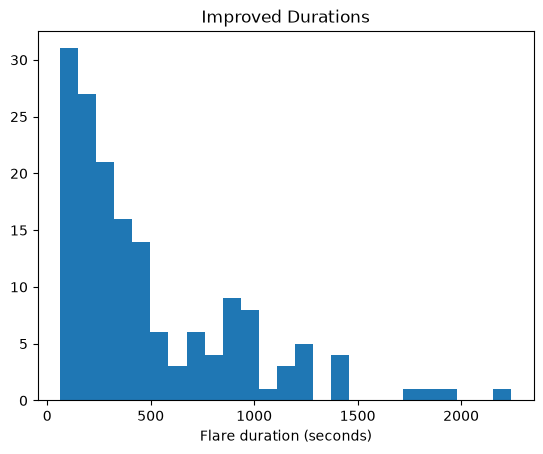

In [893]:
plt.hist(durations, bins=25)
plt.title('Improved Durations')
plt.xlabel('Flare duration (seconds)')
plt.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/improved_durations_hist.png", bbox_inches='tight')

In [987]:
np.where(np.array(durations_50100)>750)

(array([28]),)

(0.0, 700.0)

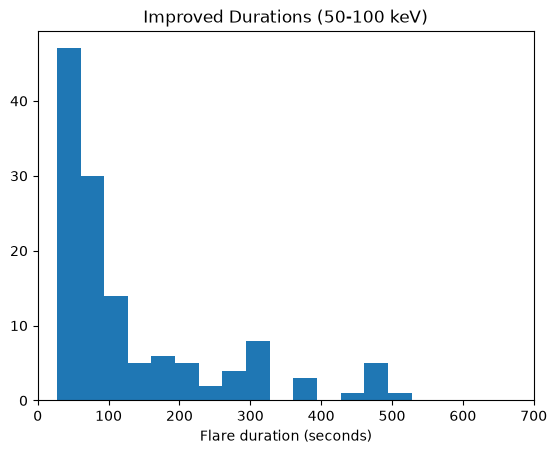

In [986]:
plt.hist(durations_50100, bins=50)
plt.title('Improved Durations (50-100 keV)')
plt.xlabel('Flare duration (seconds)')
plt.xlim(0, 700)
#plt.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/improved_durations_hist.png", bbox_inches='tight')

In [816]:
normalised_df_list = []
for df in resampled_df_list:
    normalised_df = df.copy()
    normalised_df['25.0 keV-50.0 keV'] = (df['25.0 keV-50.0 keV']-np.min(df['25.0 keV-50.0 keV']))/(np.max(df['25.0 keV-50.0 keV'])-np.min(df['25.0 keV-50.0 keV']))
    normalised_df['50.0 keV-100.0 keV'] = (df['50.0 keV-100.0 keV']- np.min(df['50.0 keV-100.0 keV']))/(np.max(df['50.0 keV-100.0 keV'])-np.min(df['50.0 keV-100.0 keV']))
    normalised_df_list.append(normalised_df)

In [972]:
timeshifted_df_list = []
timeshifted_df_list_50100 = []
i=0
for df in normalised_df_list:
    if pd.notna(starts[i]):
        timeshifted_df = df.copy()
        timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
        
        #
        start = pd.to_datetime(t(starts[i])).round('1s')
        #
        
        # total_start = (estimated_starts_x[i] - dt.datetime(2004, 11, 25)).total_seconds()
        # total_end = (estimated_ends_x[i] - dt.datetime(2004, 11, 25)).total_seconds()
    
        total_start = (start - dt.datetime(2004, 11, 25)).total_seconds()
        
        timeshifted_df.index = timeshifted_df.index - total_start
        timeshifted_df = timeshifted_df.truncate(0, max(durations))
        timeshifted_df_list.append(timeshifted_df)
    if pd.notna(starts_50100[i]):
        timeshifted_df = df.copy()
        timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
        
        start = pd.to_datetime(t(starts_50100[i])).round('1s')
    
        total_start = (start - dt.datetime(2004, 11, 25)).total_seconds()
        
        timeshifted_df.index = timeshifted_df.index - total_start
        timeshifted_df = timeshifted_df.truncate(0, max(durations_50100))
        timeshifted_df_list_50100.append(timeshifted_df)
    i+=1

In [1062]:
i=0
for df in timeshifted_df_list_50100:
    fig, ax = plt.subplots()
    ax.plot(df.index, df['50.0 keV-100.0 keV'])
    fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/test/flare"+str(i)+".png", bbox_inches='tight')
    i+=1
plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_16436\3642507524.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [1063]:
i=0
for df in timeshifted_df_list:
    fig, ax = plt.subplots()
    ax.plot(df.index, df['25.0 keV-50.0 keV'])
    fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/test_25_50/flare"+str(i)+".png", bbox_inches='tight')
    i+=1
plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_16436\575739007.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [973]:
concat_band1 = pd.concat((df['25.0 keV-50.0 keV'] for df in timeshifted_df_list), axis=1)
averaged_shape_flare_2550 = pd.DataFrame(concat_band1.mean(axis=1), columns=['25.0 keV-50.0 keV'])
median_flare_2550 = pd.DataFrame(concat_band1.median(axis=1), columns=['25.0 keV-50.0 keV'])

concat_band2 = pd.concat((df['50.0 keV-100.0 keV'] for df in timeshifted_df_list_50100), axis=1)
median_flare_50100 = pd.DataFrame(concat_band2.median(axis=1), columns=['50.0 keV-100.0 keV'])

In [974]:
std_2550_mean = concat_band1.std(axis=1)

upperlim_2550 = median_flare_2550['25.0 keV-50.0 keV']+std_2550_mean
lowerlim_2550 = median_flare_2550['25.0 keV-50.0 keV']-std_2550_mean

for i in np.arange(0, len(upperlim_2550), 1):
    if lowerlim_2550.iloc[i]<0:
        lowerlim_2550.iloc[i] = 0

std_50100_mean = concat_band2.std(axis=1)

upperlim_50100 = median_flare_50100['50.0 keV-100.0 keV']+std_50100_mean
lowerlim_50100 = median_flare_50100['50.0 keV-100.0 keV']-std_50100_mean

for i in np.arange(0, len(upperlim_50100), 1):
    if lowerlim_50100.iloc[i]<0:
        lowerlim_50100.iloc[i] = 0

(-50.0, 1050.0)

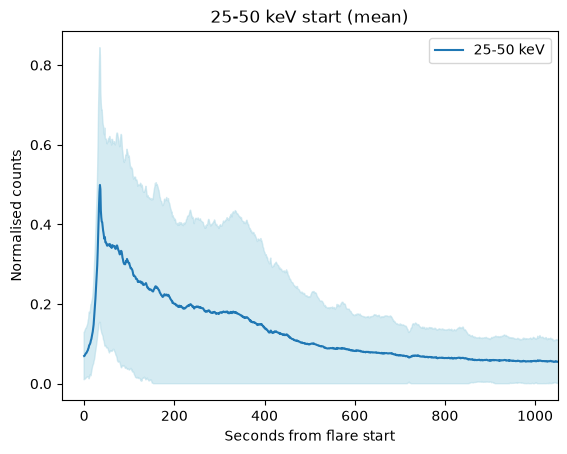

In [851]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_2550.index, averaged_shape_flare_2550['25.0 keV-50.0 keV'], label='25-50 keV')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.title('25-50 keV start (mean)')
ax.legend()

ax.fill_between(averaged_shape_flare_2550.index, lowerlim_2550, upperlim_2550, color='lightblue', alpha=0.5)
ax.set_xlim(-50, 1050)
#fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/improved_duration_sea_mean.png", bbox_inches='tight')

(-50.0, 1050.0)

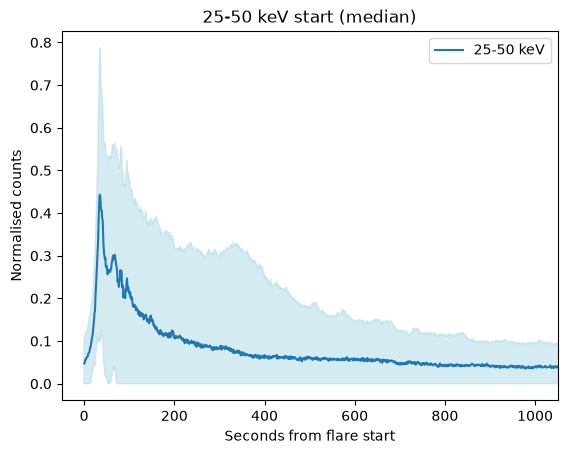

In [970]:
fig, ax = plt.subplots()

ax.plot(median_flare_2550.index, median_flare_2550['25.0 keV-50.0 keV'], label='25-50 keV')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.title('25-50 keV start (median)')
ax.legend()

ax.fill_between(averaged_shape_flare_2550.index, lowerlim_2550, upperlim_2550, color='lightblue', alpha=0.5)
ax.set_xlim(-50, 1050)

#fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/improved_duration_sea_median.png", bbox_inches='tight')

(-50.0, 550.0)

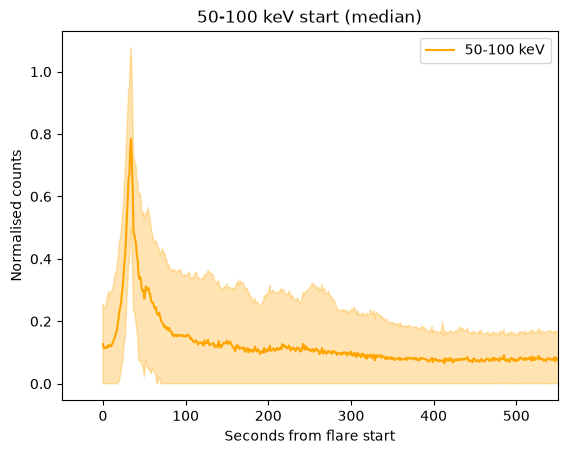

In [979]:
fig, ax = plt.subplots()

ax.plot(median_flare_50100.index, median_flare_50100['50.0 keV-100.0 keV'], label='50-100 keV', color='orange')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.title('50-100 keV start (median)')
ax.legend()

ax.fill_between(median_flare_50100.index, lowerlim_50100, upperlim_50100, color='orange', alpha=0.3)
ax.set_xlim(-50, 550)

#fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/improved_duration_sea_median.png", bbox_inches='tight')

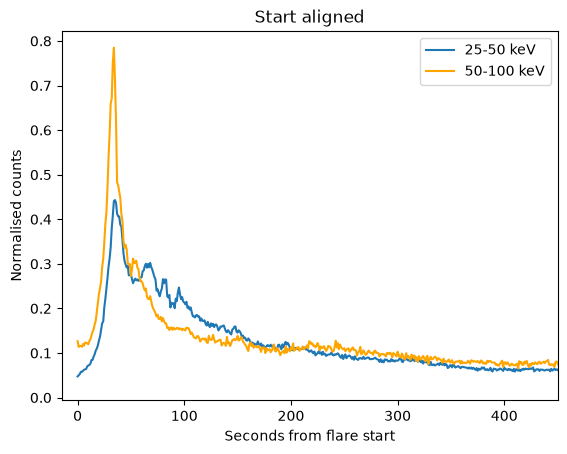

In [1055]:
fig, ax = plt.subplots()

ax.plot(median_flare_2550.index, median_flare_2550['25.0 keV-50.0 keV'], label='25-50 keV')
ax.plot(median_flare_50100.index, median_flare_50100['50.0 keV-100.0 keV'], label='50-100 keV', color='orange')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.title('Start aligned')
ax.legend()

ax.set_xlim(-15, 450)

fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/start_aligned_bothbands.png", bbox_inches='tight')

In [1037]:
n = concat_band2.notna().sum(axis=1)
print(concat_band2.shape, n.max(), n.median())

(1697, 132) 132 132.0


In [1041]:
np.where(n<132)

(array([], dtype=int64),)

In [822]:
i=0
for df in timeshifted_df_list:
    fig, ax = plt.subplots()
    ax.set_ylabel('ct/(keV s)')
    ax.set_title(f"{parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime.year}-{parse_time(flarelist['start_UTC'].iloc[i]).datetime.month}-{parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime.day} {parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime.hour}:{parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime.minute}")
    ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))
    
    ax.plot(averaged_shape_flare_2550.index, averaged_shape_flare_2550['25.0 keV-50.0 keV'], label='Start normalised SEA')
    ax.plot(df.index, df['25.0 keV-50.0 keV'], label='25-50 keV')
    
    ax.set_xlabel('Seconds from flare start')
    ax.set_ylabel('Normalised counts')
    
    ax.fill_between(averaged_shape_flare_2550.index, lowerlim_2550, upperlim_2550, color='lightblue', alpha=0.5)
    
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize='small')
    fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/SEA_flare_comparisons/flare"+str(i)+".png", bbox_inches='tight')
    i+=1

plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_16436\744836776.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [728]:
len(no_file)

42

In [729]:
timeshifted_df_list_durations = []
i=0
for df in normalised_df_list:
    if pd.notna(durations[i]):
        timeshifted_df = df.copy()
        timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
        
        #
        start = pd.to_datetime(t(starts[i])).round('1s')
        end = pd.to_datetime(t(ends[i])).round('1s')
        #
    
        total_start = (start - dt.datetime(2004, 11, 25)).total_seconds()
        total_end = (end - dt.datetime(2004, 11, 25)).total_seconds()
    
        
        timeshifted_df.index = timeshifted_df.index - total_start
        timeshifted_df = timeshifted_df.truncate(0, total_end-total_start)
        timeshifted_df.index = timeshifted_df.index/(total_end-total_start)
        timeshifted_df_list_durations.append(timeshifted_df)
    i+=1

In [730]:
resampled_ind = np.linspace(0, 1, 1000)

resampled_duration_norm = []
for df in timeshifted_df_list_durations:
    resampled_df = df.reindex(df.index.union(resampled_ind)).interpolate('linear').loc[resampled_ind]
    resampled_duration_norm.append(resampled_df)

In [731]:
concat_band1_dur = pd.concat((df['25.0 keV-50.0 keV'] for df in resampled_duration_norm), axis=1)
averaged_shape_flare_2550_dur = pd.DataFrame(concat_band1_dur.mean(axis=1), columns=['25.0 keV-50.0 keV'])
median_flare_2550_dur = pd.DataFrame(concat_band1_dur.median(axis=1), columns=['25.0 keV-50.0 keV'])

In [732]:
std_2550_dur = concat_band1_dur.std(axis=1)

upperlim_2550_dur = averaged_shape_flare_2550_dur['25.0 keV-50.0 keV']+std_2550_dur
lowerlim_2550_dur = averaged_shape_flare_2550_dur['25.0 keV-50.0 keV']-std_2550_dur

for i in np.arange(0, len(upperlim_2550_dur), 1):
    if lowerlim_2550_dur.iloc[i]<0:
        lowerlim_2550_dur.iloc[i] = 0

In [733]:
len(averaged_shape_flare_2550_dur)

1000

In [734]:
len(upperlim_2550_dur)

1000

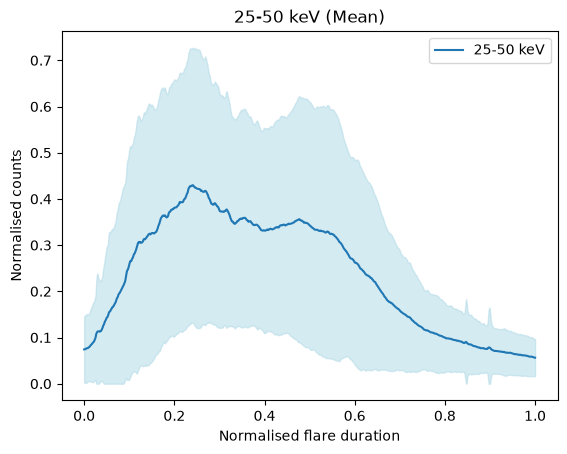

In [735]:
fig, ax = plt.subplots()

ax.plot(averaged_shape_flare_2550_dur.index, averaged_shape_flare_2550_dur['25.0 keV-50.0 keV'], label='25-50 keV')
#ax.plot(averaged_shape_flare_2550.index, averaged_shape_flare_2550['25.0 keV-50.0 keV'], label='25-50 keV')
plt.xlabel('Normalised flare duration')
plt.ylabel('Normalised counts')
plt.title('25-50 keV (Mean)')
ax.legend()

ax.fill_between(averaged_shape_flare_2550_dur.index, lowerlim_2550_dur, upperlim_2550_dur, color='lightblue', alpha=0.5)
#ax.set_xlim(-50, 1050)
#fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/improved_duration_sea_fullnorm_mean.png", bbox_inches='tight')

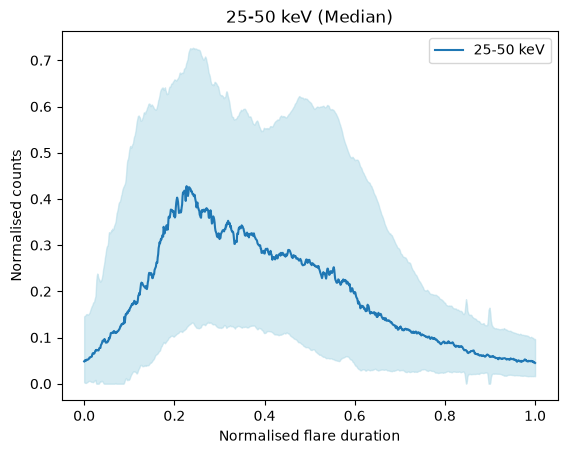

In [736]:
fig, ax = plt.subplots()

ax.plot(median_flare_2550_dur.index, median_flare_2550_dur['25.0 keV-50.0 keV'], label='25-50 keV')
#ax.plot(averaged_shape_flare_2550.index, averaged_shape_flare_2550['25.0 keV-50.0 keV'], label='25-50 keV')
plt.xlabel('Normalised flare duration')
plt.ylabel('Normalised counts')
plt.title('25-50 keV (Median)')
ax.legend()

ax.fill_between(averaged_shape_flare_2550_dur.index, lowerlim_2550_dur, upperlim_2550_dur, color='lightblue', alpha=0.5)
#ax.set_xlim(-50, 1050)
fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/improved_duration_sea_fullnorm_median.png", bbox_inches='tight')

In [895]:
durations_f = []
for d in durations:
    if pd.notna(d):
        durations_f.append(d)
    

In [824]:
timeshifted_df_list_f = []
i=0
for df in normalised_df_list:
    if pd.notna(durations[i]):
        timeshifted_df = df.copy()
        timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
        
        #
        start = pd.to_datetime(t(starts[i])).round('1s')
        #
        
        # total_start = (estimated_starts_x[i] - dt.datetime(2004, 11, 25)).total_seconds()
        # total_end = (estimated_ends_x[i] - dt.datetime(2004, 11, 25)).total_seconds()
    
        total_start = (start - dt.datetime(2004, 11, 25)).total_seconds()
        
        timeshifted_df.index = timeshifted_df.index - total_start
        timeshifted_df = timeshifted_df.truncate(0, max(durations))
        timeshifted_df_list_f.append(timeshifted_df)
    i+=1

In [942]:
long_flares = []
longflare_locs = []
for i in list(np.where(np.array(durations_f)>=300)[0]):
    long_flares.append(timeshifted_df_list[i])
    longflare_locs.append(i)

short_flares = []
shortflare_locs = []
for i in list(np.where(np.array(durations_f)<300)[0]):
    short_flares.append(timeshifted_df_list[i])
    shortflare_locs.append(i)

In [844]:
concat_band1_long = pd.concat((df['25.0 keV-50.0 keV'] for df in long_flares), axis=1)
averaged_shape_flare_2550_long = pd.DataFrame(concat_band1_long.mean(axis=1), columns=['25.0 keV-50.0 keV'])
median_flare_2550_long = pd.DataFrame(concat_band1_long.median(axis=1), columns=['25.0 keV-50.0 keV'])

concat_band1_short = pd.concat((df['25.0 keV-50.0 keV'] for df in short_flares), axis=1)
averaged_shape_flare_2550_short = pd.DataFrame(concat_band1_short.mean(axis=1), columns=['25.0 keV-50.0 keV'])
median_flare_2550_short = pd.DataFrame(concat_band1_short.median(axis=1), columns=['25.0 keV-50.0 keV'])

In [845]:
concat_band1_long.shape

(2243, 85)

In [846]:
concat_band1_short.shape

(2243, 77)

In [847]:
std_2550_long = concat_band1_long.std(axis=1)

upperlim_2550_long = averaged_shape_flare_2550_long['25.0 keV-50.0 keV']+std_2550_long
lowerlim_2550_long = averaged_shape_flare_2550_long['25.0 keV-50.0 keV']-std_2550_long

for i in np.arange(0, len(upperlim_2550_long), 1):
    if lowerlim_2550_long.iloc[i]<0:
        lowerlim_2550_long.iloc[i] = 0

std_2550_short = concat_band1_short.std(axis=1)

upperlim_2550_short = averaged_shape_flare_2550_short['25.0 keV-50.0 keV']+std_2550_short
lowerlim_2550_short = averaged_shape_flare_2550_short['25.0 keV-50.0 keV']-std_2550_short

for i in np.arange(0, len(upperlim_2550_short), 1):
    if lowerlim_2550_short.iloc[i]<0:
        lowerlim_2550_short.iloc[i] = 0

(-50.0, 1050.0)

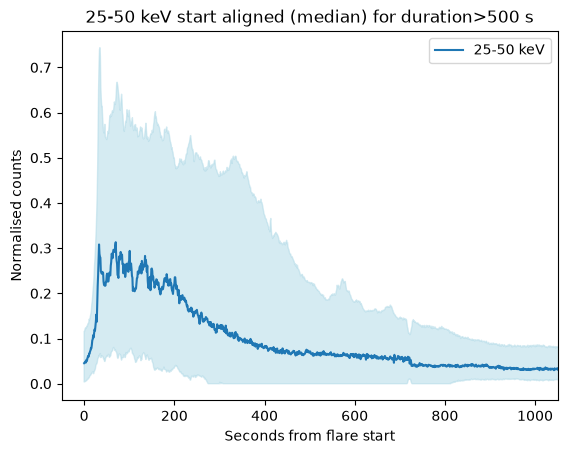

In [848]:
fig, ax = plt.subplots()

ax.plot(median_flare_2550_long.index, median_flare_2550_long['25.0 keV-50.0 keV'], label='25-50 keV')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.title('25-50 keV start aligned (median) for duration>500 s')
ax.legend()

ax.fill_between(median_flare_2550_long.index, lowerlim_2550_long, upperlim_2550_long, color='lightblue', alpha=0.5)
ax.set_xlim(-50, 1050)

#fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/improved_duration_sea_median.png", bbox_inches='tight')

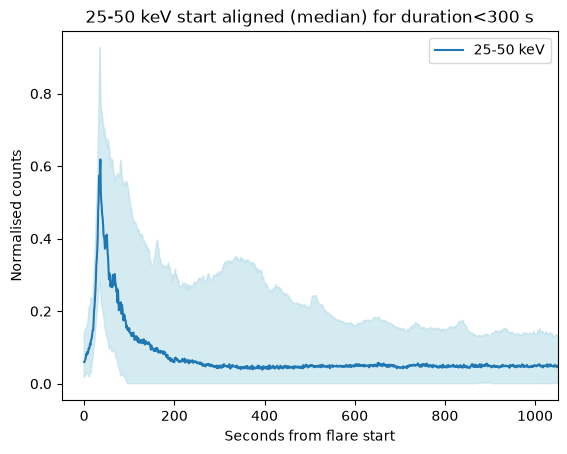

In [849]:
fig, ax = plt.subplots()

ax.plot(median_flare_2550_short.index, median_flare_2550_short['25.0 keV-50.0 keV'], label='25-50 keV')
plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
plt.title('25-50 keV start aligned (median) for duration<300 s')
ax.legend()
ax.set_xlim(-50, 1050)
ax.fill_between(median_flare_2550_short.index, lowerlim_2550_short, upperlim_2550_short, color='lightblue', alpha=0.5)

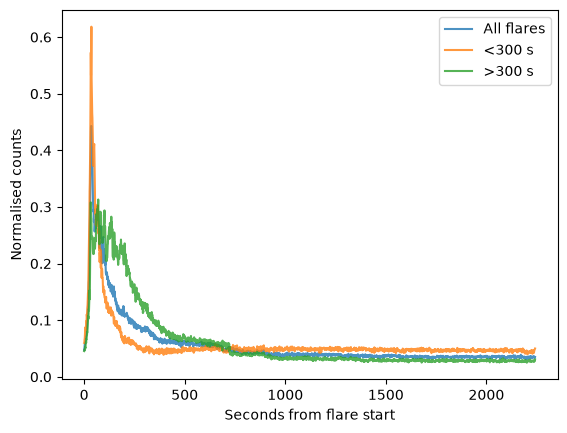

In [832]:
fig, ax = plt.subplots()

ax.plot(median_flare_2550.index, median_flare_2550['25.0 keV-50.0 keV'], label='All flares', alpha=0.8)
#ax.fill_between(median_flare_2550.index, lowerlim_2550, upperlim_2550, color='lightblue', alpha=0.5)

ax.plot(median_flare_2550_short.index, median_flare_2550_short['25.0 keV-50.0 keV'], label='<300 s', alpha=0.8)
#ax.fill_between(median_flare_2550_short.index, lowerlim_2550_short, upperlim_2550_short, color='orange', alpha=0.3)

ax.plot(median_flare_2550_long.index, median_flare_2550_long['25.0 keV-50.0 keV'], label='>300 s', alpha=0.8)
#ax.fill_between(median_flare_2550_long.index, lowerlim_2550_long, upperlim_2550_long, color='green', alpha=0.3)

plt.xlabel('Seconds from flare start')
plt.ylabel('Normalised counts')
ax.legend()

In [964]:
peak_counts = []
peak_locs = []
i=0
for df in df_list_refined:
    if pd.notna(durations[i]):
        peak = np.max(df['25.0 keV-50.0 keV'])
        scaled_peak = peak/flarelist_refined['solo_position_AU_distance'].iloc[i]
        peak_counts.append(scaled_peak)
        peak_loc = df.index[df['25.0 keV-50.0 keV'] == peak][0]
        peak_locs.append(peak_loc)
    i+=1

peak_ratios = []
i=0
for df in df_list_refined:
    if pd.notna(durations[i]):
        peak_2550 = np.max(df['25.0 keV-50.0 keV'])
        peak_50100 = np.max(df['50.0 keV-100.0 keV'])
        ratio = peak_50100/peak_2550
        peak_ratios.append(ratio)
    i+=1

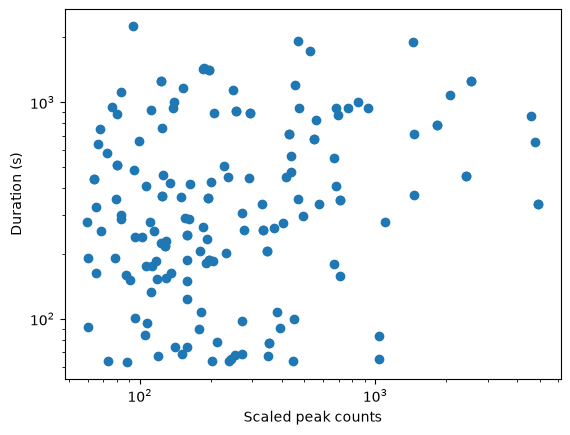

In [897]:
fig, ax = plt.subplots()
ax.scatter(peak_counts, durations_f)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Duration (s)')
ax.set_xlabel('Scaled peak counts')
fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/improved_durations_peak_counts_vs_duration.png", bbox_inches='tight')

In [835]:
from scipy.stats import spearmanr, pearsonr
spearmanr(peak_counts, durations_f)

SignificanceResult(statistic=np.float64(0.20004304688163638), pvalue=np.float64(0.010702422978622362))

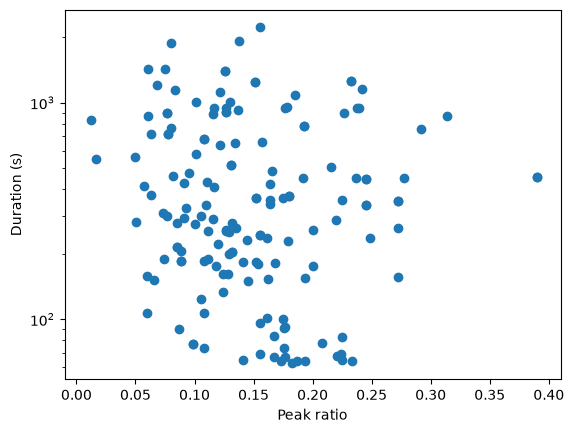

In [898]:
fig, ax = plt.subplots()
ax.scatter(peak_ratios, durations_f)
ax.set_yscale('log')
ax.set_ylabel('Duration (s)')
ax.set_xlabel('Peak ratio')
ax.set_xlim(-0.01, 0.41)
fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/improved_durations_peak_ratios_vs_duration.png", bbox_inches='tight')

In [837]:
spearmanr(peak_ratios, durations_f)

SignificanceResult(statistic=np.float64(-0.10703609508128926), pvalue=np.float64(0.1751960284036423))

In [1102]:
resampled_df_list_peaks = []
i=0
for df in df_list_refined:
    #df = df.truncate(starts[i], starts[i]+dt.timedelta(seconds=max(durations)))
    resampled_df = df.resample('1s').mean()
    resampled_df['25.0 keV-50.0 keV'] = resampled_df['25.0 keV-50.0 keV'].interpolate('linear')
    resampled_df['50.0 keV-100.0 keV'] = resampled_df['50.0 keV-100.0 keV'].interpolate('linear')
    resampled_df_list_peaks.append(resampled_df)
    i+=1

normalised_df_list_peaks = []
i=0
for df in resampled_df_list_peaks:
    normalised_df = df.copy()
    if pd.notna(durations[i]):
        df = df.truncate(starts[i], ends[i])
    normalised_df['25.0 keV-50.0 keV'] = (df['25.0 keV-50.0 keV']-np.min(df['25.0 keV-50.0 keV']))/(np.max(df['25.0 keV-50.0 keV'])-np.min(df['25.0 keV-50.0 keV']))
    normalised_df['50.0 keV-100.0 keV'] = (df['50.0 keV-100.0 keV']- np.min(df['50.0 keV-100.0 keV']))/(np.max(df['50.0 keV-100.0 keV'])-np.min(df['50.0 keV-100.0 keV']))
    normalised_df_list_peaks.append(normalised_df)
    i+=1

In [1103]:
df_list_filtered = []
for df in resampled_df_list_peaks:
    df_filtered = df.copy()
    
    filtered_2550 = savgol_filter(df['25.0 keV-50.0 keV'], window_length = 25, polyorder=2)
    filtered_50100 = savgol_filter(df['50.0 keV-100.0 keV'], window_length = 25, polyorder=2)

    df_filtered['25.0 keV-50.0 keV'] = filtered_2550
    df_filtered['50.0 keV-100.0 keV'] = filtered_50100

    df_list_filtered.append(df_filtered)

In [1198]:
i=0
firstpeaks = []
firstpeaks_50100 = []
for df in df_list_filtered:
    start = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime - dt.timedelta(minutes=10)
    end = parse_time(flarelist_refined['end_UTC'].iloc[i]).datetime  + dt.timedelta(minutes=10)
    
    df = df.truncate(start, end)
    peak_counts=np.max(df['25.0 keV-50.0 keV'])
    peaks, properties = find_peaks(df['25.0 keV-50.0 keV'], prominence=0.05*peak_counts) #distance=15,
    firstpeaks.append(peaks[0])

    start = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime - dt.timedelta(minutes=10)
    end = parse_time(flarelist_refined['end_UTC'].iloc[i]).datetime  + dt.timedelta(minutes=10)
    
    df = df.truncate(start, end)
    peak_counts=np.max(df['50.0 keV-100.0 keV'])
    peaks, properties = find_peaks(df['50.0 keV-100.0 keV'], prominence=0.1*peak_counts) #distance=15,
    firstpeaks_50100.append(peaks[0])
    
    # df = df_list_refined[i]
    # df = df.truncate(starts[i], ends[i])
    # fig, ax = plt.subplots()
    # ax.plot(df. index, df['25.0 keV-50.0 keV'])
    # ax.scatter(df.index[peaks], df['25.0 keV-50.0 keV'].iloc[peaks], color='black', marker='*')
    # fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_9/peak_testing/flare"+str(i)+".png", bbox_inches='tight')
    
    
    i+=1

# plt.close('all')

In [1105]:
timeshifted_df_list_firstpeak = []
i=0
for df in normalised_df_list_peaks:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()

    start = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime - dt.timedelta(minutes=10)
    end = parse_time(flarelist_refined['end_UTC'].iloc[i]).datetime  + dt.timedelta(minutes=10)
    
    #
    df = df.truncate(start, end)
    peak_time = df.index[firstpeaks[i]]
    peak_time = pd.to_datetime(t(peak_time)).round('1s')
    #

    total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_peak_time
    timeshifted_df = timeshifted_df.truncate(-200, 1800)
    timeshifted_df_list_firstpeak.append(timeshifted_df)
    i+=1

firstpeak_list = []
for df in timeshifted_df_list_firstpeak:
    new_index = pd.Index(np.arange(-200, 1800, 1)) 
    df = df.set_index(df.index).reindex(new_index)
    firstpeak_list.append(df)

In [1106]:
timeshifted_df_list_firstpeak_50100 = []
i=0
for df in normalised_df_list_peaks:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()

    start = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime - dt.timedelta(minutes=10)
    end = parse_time(flarelist_refined['end_UTC'].iloc[i]).datetime  + dt.timedelta(minutes=10)
    
    #
    df = df.truncate(start, end)
    peak_time = df.index[firstpeaks_50100[i]]
    peak_time = pd.to_datetime(t(peak_time)).round('1s')
    #

    total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_peak_time
    timeshifted_df = timeshifted_df.truncate(-200, 1800)
    timeshifted_df_list_firstpeak_50100.append(timeshifted_df)
    i+=1

firstpeak_list_50100 = []
for df in timeshifted_df_list_firstpeak_50100:
    new_index = pd.Index(np.arange(-200, 1800, 1)) 
    df = df.set_index(df.index).reindex(new_index)
    firstpeak_list_50100.append(df)

In [1107]:
concat_band1_firstpeak = pd.concat((df['25.0 keV-50.0 keV'] for df in firstpeak_list), axis=1)
averaged_shape_flare_2550_firstpeak = pd.DataFrame(concat_band1_firstpeak.mean(axis=1), columns=['25.0 keV-50.0 keV'])
median_2550_firstpeak = pd.DataFrame(concat_band1_firstpeak.median(axis=1), columns=['25.0 keV-50.0 keV'])

std_2550_mean_firstpeak = concat_band1_firstpeak.std(axis=1)

upperlim_2550_firstpeak = median_2550_firstpeak['25.0 keV-50.0 keV']+std_2550_mean_firstpeak
lowerlim_2550_firstpeak = median_2550_firstpeak['25.0 keV-50.0 keV']-std_2550_mean_firstpeak

for i in np.arange(0, len(upperlim_2550_firstpeak), 1):
    if lowerlim_2550_firstpeak.iloc[i]<0:
        lowerlim_2550_firstpeak.iloc[i] = 0

In [1108]:
concat_band2_firstpeak = pd.concat((df['50.0 keV-100.0 keV'] for df in firstpeak_list_50100), axis=1)
averaged_shape_flare_50100_firstpeak = pd.DataFrame(concat_band1_firstpeak.mean(axis=1), columns=['50.0 keV-100.0 keV'])
median_50100_firstpeak = pd.DataFrame(concat_band2_firstpeak.median(axis=1), columns=['50.0 keV-100.0 keV'])

std_50100_mean_firstpeak = concat_band2_firstpeak.std(axis=1)

upperlim_50100_firstpeak = median_50100_firstpeak['50.0 keV-100.0 keV'] +std_50100_mean_firstpeak
lowerlim_50100_firstpeak = median_50100_firstpeak['50.0 keV-100.0 keV'] -std_50100_mean_firstpeak

for i in np.arange(0, len(upperlim_50100_firstpeak), 1):
    if lowerlim_50100_firstpeak.iloc[i]<0:
        lowerlim_50100_firstpeak.iloc[i] = 0

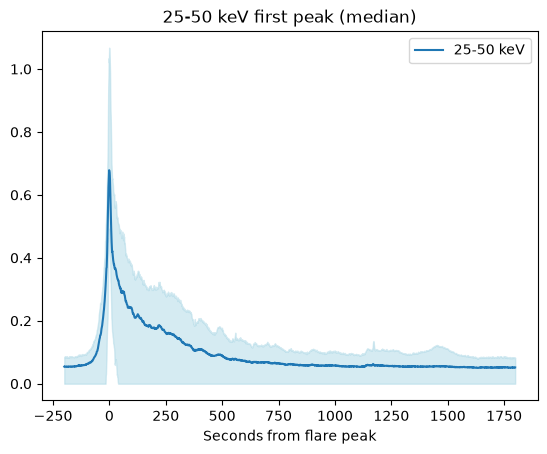

In [1030]:
fig, ax = plt.subplots()

ax.plot(median_2550_firstpeak.index, averaged_shape_flare_2550_firstpeak['25.0 keV-50.0 keV'], label = '25-50 keV')
ax.fill_between(median_2550_firstpeak.index, lowerlim_2550_firstpeak, upperlim_2550_firstpeak, color='lightblue', alpha=0.5)
ax.set_xlabel('Seconds from flare peak')
ax.set_title('25-50 keV first peak (median)')
ax.legend()

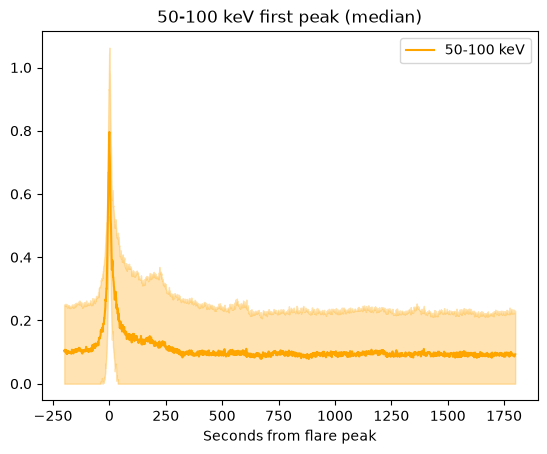

In [1031]:
fig, ax = plt.subplots()

ax.plot(median_50100_firstpeak.index, median_50100_firstpeak['50.0 keV-100.0 keV'], label = '50-100 keV', color='orange')
ax.fill_between(median_50100_firstpeak.index, lowerlim_50100_firstpeak, upperlim_50100_firstpeak, color='orange', alpha=0.3)
ax.set_xlabel('Seconds from flare peak')
ax.set_title('50-100 keV first peak (median)')
ax.legend()

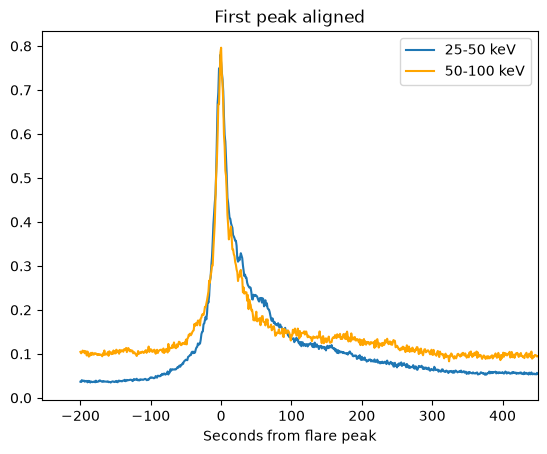

In [1050]:
fig, ax = plt.subplots()

ax.plot(median_2550_firstpeak.index, median_2550_firstpeak['25.0 keV-50.0 keV'], label = '25-50 keV')
ax.plot(median_50100_firstpeak.index, median_50100_firstpeak['50.0 keV-100.0 keV'], label = '50-100 keV', color='orange')
ax.set_xlabel('Seconds from flare peak')
ax.set_title('First peak aligned')
ax.legend()
ax.set_xlim(-255, 450)

fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/firstpeak_aligned_bothbands.png", bbox_inches='tight')

In [859]:
timeshifted_peaks_df_list = []
i=0
for df in normalised_df_list_peaks:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
    #
    peak_time = df.index[df['25.0 keV-50.0 keV'] == np.max(df['25.0 keV-50.0 keV'])][0]
    peak_time = pd.to_datetime(t(peak_time)).round('1s')
    #

    total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_peak_time
    timeshifted_df = timeshifted_df.truncate(-1000, 1000)
    timeshifted_peaks_df_list.append(timeshifted_df)
    i+=1

ts_peaks_list = []
for df in timeshifted_peaks_df_list:
    new_index = pd.Index(np.arange(-1000, 1000, 1)) 
    df = df.set_index(df.index).reindex(new_index)
    ts_peaks_list.append(df)

In [996]:
timeshifted_peaks_df_list_50100 = []
i=0
for df in normalised_df_list_peaks:
    timeshifted_df = df.copy()
    timeshifted_df.index = (timeshifted_df.index - dt.datetime(2004, 11, 25)).total_seconds()
    
    #
    peak_time = df.index[df['50.0 keV-100.0 keV'] == np.max(df['50.0 keV-100.0 keV'])][0]
    peak_time = pd.to_datetime(t(peak_time)).round('1s')
    #

    total_peak_time = (peak_time - dt.datetime(2004, 11, 25)).total_seconds()
    
    timeshifted_df.index = timeshifted_df.index - total_peak_time
    timeshifted_df = timeshifted_df.truncate(-1000, 1000)
    timeshifted_peaks_df_list_50100.append(timeshifted_df)
    i+=1

ts_peaks_list_50100 = []
for df in timeshifted_peaks_df_list_50100:
    new_index = pd.Index(np.arange(-1000, 1000, 1)) 
    df = df.set_index(df.index).reindex(new_index)
    ts_peaks_list_50100.append(df)

In [997]:
concat_band1_peaks = pd.concat((df['25.0 keV-50.0 keV'] for df in ts_peaks_list), axis=1)
averaged_shape_flare_2550_peaks = pd.DataFrame(concat_band1_peaks.mean(axis=1), columns=['25.0 keV-50.0 keV'])
median_2550_peaks = pd.DataFrame(concat_band1_peaks.median(axis=1), columns=['25.0 keV-50.0 keV'])

concat_band2_peaks = pd.concat((df['50.0 keV-100.0 keV'] for df in ts_peaks_list_50100), axis=1)
averaged_shape_flare_50100_peaks = pd.DataFrame(concat_band2_peaks.mean(axis=1), columns=['50.0 keV-100.0 keV'])
median_50100_peaks = pd.DataFrame(concat_band2_peaks.median(axis=1), columns=['50.0 keV-100.0 keV'])

In [998]:
std_2550_peaks = concat_band1_peaks.std(axis=1)

upperlim_2550_peaks = median_2550_peaks['25.0 keV-50.0 keV']+std_2550_peaks
lowerlim_2550_peaks = median_2550_peaks['25.0 keV-50.0 keV']-std_2550_peaks

for i in np.arange(-1000, 1000, 1):
    if lowerlim_2550_peaks.iloc[i]<0:
        lowerlim_2550_peaks.iloc[i] = 0

std_50100_peaks = concat_band2_peaks.std(axis=1)

upperlim_50100_peaks = median_50100_peaks['50.0 keV-100.0 keV']+std_2550_peaks
lowerlim_50100_peaks = median_50100_peaks['50.0 keV-100.0 keV']-std_2550_peaks

for i in np.arange(-1000, 1000, 1):
    if lowerlim_50100_peaks.iloc[i]<0:
        lowerlim_50100_peaks.iloc[i] = 0

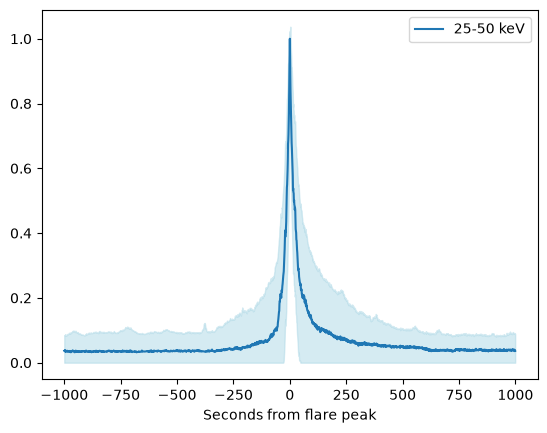

In [1056]:
fig, ax = plt.subplots()

ax.plot(median_2550_peaks.index, median_2550_peaks['25.0 keV-50.0 keV'], label = '25-50 keV')
ax.fill_between(median_2550_peaks.index, lowerlim_2550_peaks, upperlim_2550_peaks, color='lightblue', alpha=0.5)
ax.set_xlabel('Seconds from flare peak')
ax.legend()

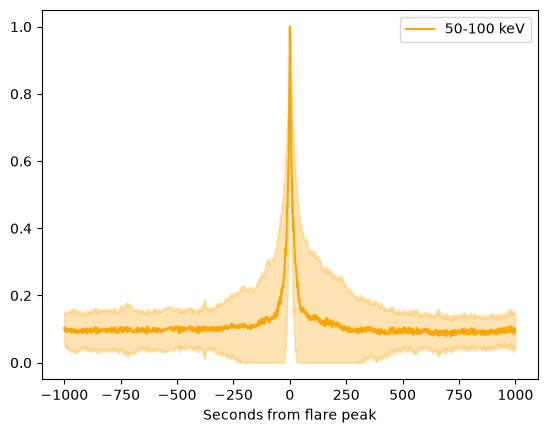

In [1000]:
fig, ax = plt.subplots()

ax.plot(median_50100_peaks.index, median_50100_peaks['50.0 keV-100.0 keV'], label = '50-100 keV', color='orange')
ax.fill_between(median_50100_peaks.index, lowerlim_50100_peaks, upperlim_50100_peaks, color='orange', alpha=0.3)
ax.set_xlabel('Seconds from flare peak')
ax.legend()

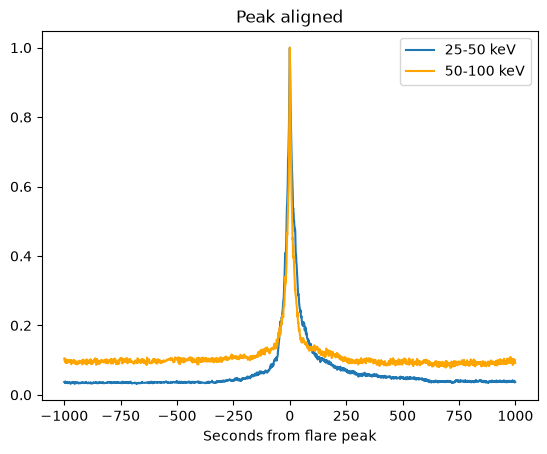

In [1059]:
fig, ax = plt.subplots()

ax.plot(median_2550_peaks.index, median_2550_peaks['25.0 keV-50.0 keV'], label = '25-50 keV')
ax.plot(median_50100_peaks.index, median_50100_peaks['50.0 keV-100.0 keV'], label = '50-100 keV', color='orange')
ax.set_xlabel('Seconds from flare peak')
ax.legend()
ax.set_title('Peak aligned')

fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/peak_aligned_bothbands.png", bbox_inches='tight')

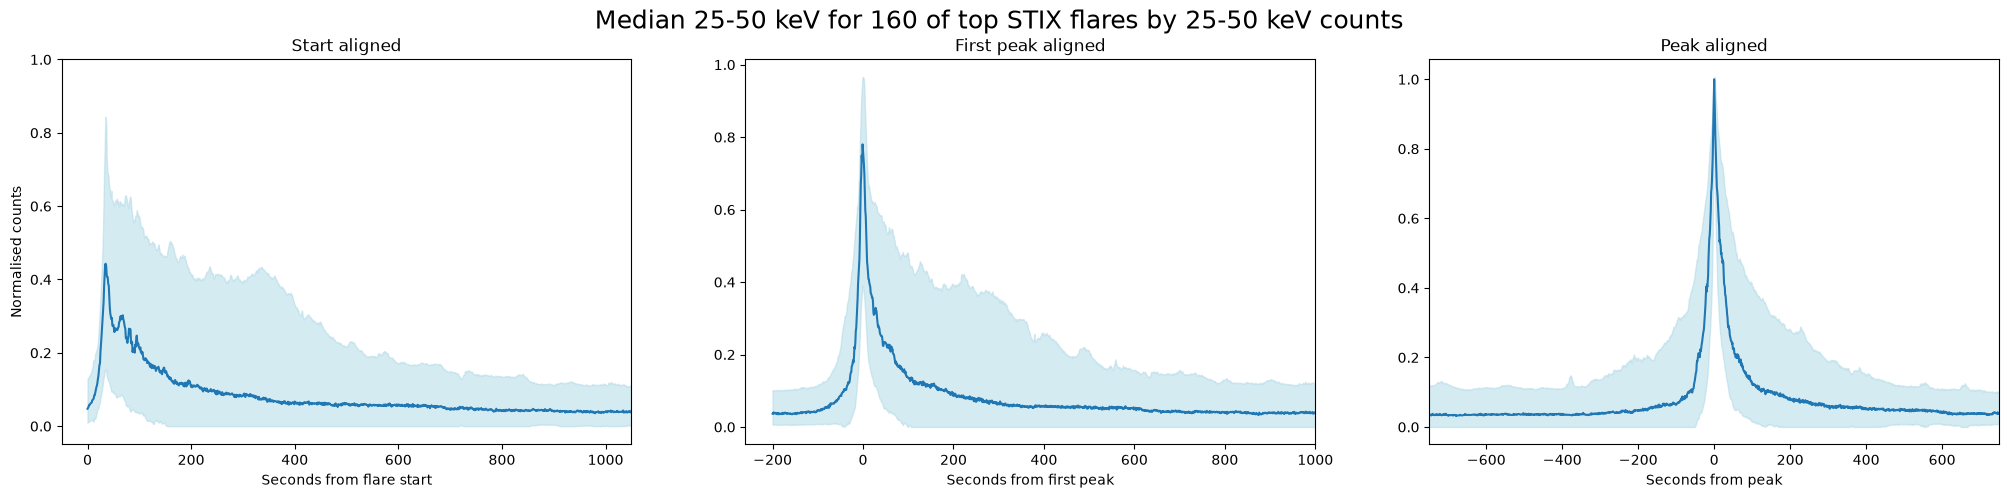

In [883]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(25, 5))
fig.suptitle('Median 25-50 keV for 160 of top STIX flares by 25-50 keV counts', fontsize=18)

start_ax = axes[0]
start_ax.plot(median_flare_2550.index, median_flare_2550['25.0 keV-50.0 keV'])
start_ax.set_xlabel('Seconds from flare start')
start_ax.set_ylabel('Normalised counts')
start_ax.set_title('Start aligned')
start_ax.fill_between(averaged_shape_flare_2550.index, lowerlim_2550, upperlim_2550, color='lightblue', alpha=0.5)
start_ax.set_xlim(-50, 1050)
start_ax.set_ylim(-0.05, 1)

fp_ax = axes[1]
fp_ax.plot(median_2550_firstpeak.index, median_2550_firstpeak['25.0 keV-50.0 keV'])
fp_ax.set_xlabel('Seconds from first peak')
fp_ax.set_title('First peak aligned')
fp_ax.fill_between(median_2550_firstpeak.index, lowerlim_2550_firstpeak, upperlim_2550_firstpeak, color='lightblue', alpha=0.5)
fp_ax.set_xlim(-260, 1000)

peak_ax = axes[2]
peak_ax.plot(median_2550_peaks.index, median_2550_peaks['25.0 keV-50.0 keV'])
peak_ax.set_xlabel('Seconds from peak')
peak_ax.set_title('Peak aligned')
peak_ax.fill_between(median_2550_peaks.index, lowerlim_2550_peaks, upperlim_2550_peaks, color='lightblue', alpha=0.5)
peak_ax.set_xlim(-750, 750)

fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/sea_comparison.png", bbox_inches='tight')

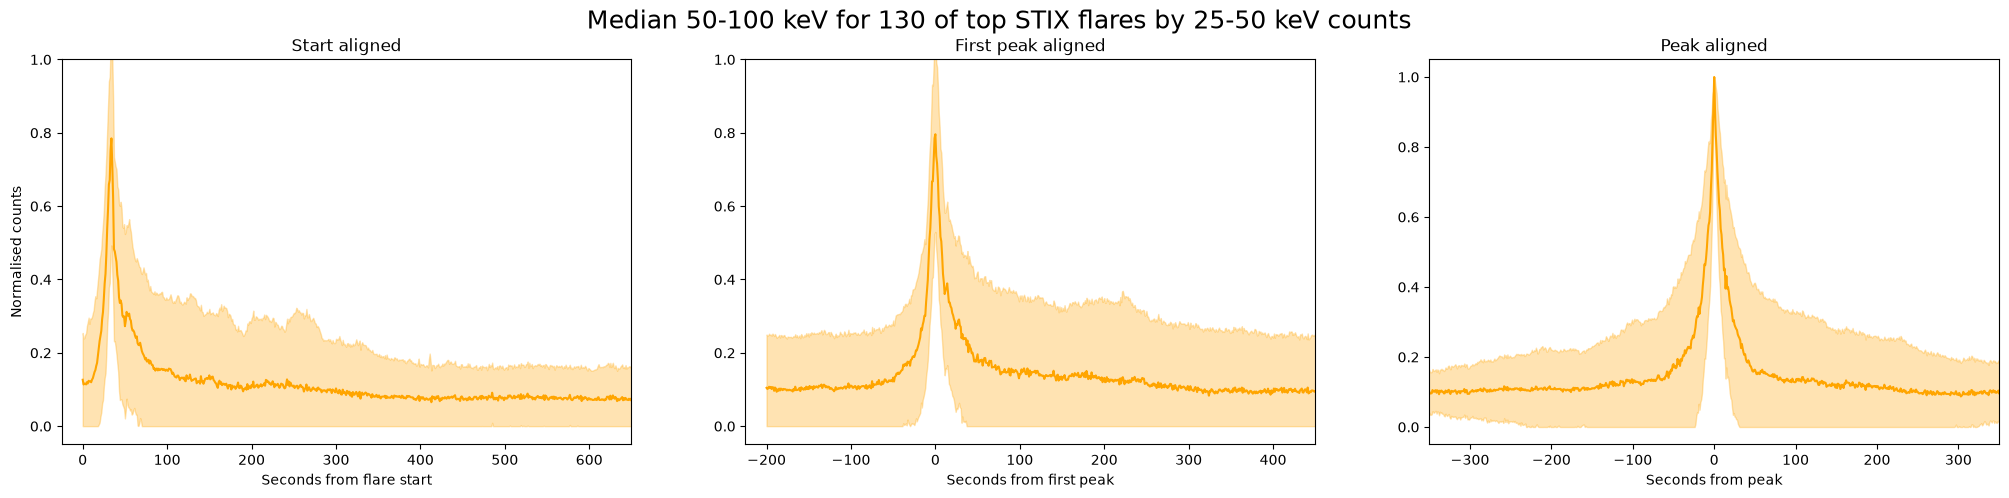

In [1045]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(25, 5))
fig.suptitle('Median 50-100 keV for 130 of top STIX flares by 25-50 keV counts', fontsize=18)

start_ax = axes[0]
start_ax.plot(median_flare_50100.index, median_flare_50100['50.0 keV-100.0 keV'], color='orange')
start_ax.set_xlabel('Seconds from flare start')
start_ax.set_ylabel('Normalised counts')
start_ax.set_title('Start aligned')
start_ax.fill_between(median_flare_50100.index, lowerlim_50100, upperlim_50100, color='orange', alpha=0.3)
start_ax.set_xlim(-25, 650)
start_ax.set_ylim(-0.05, 1)

fp_ax = axes[1]
fp_ax.plot(median_50100_firstpeak.index, median_50100_firstpeak['50.0 keV-100.0 keV'], color='orange')
fp_ax.set_xlabel('Seconds from first peak')
fp_ax.set_title('First peak aligned')
fp_ax.fill_between(median_50100_firstpeak.index, lowerlim_50100_firstpeak, upperlim_50100_firstpeak, color='orange', alpha=0.3)
fp_ax.set_xlim(-225, 450)
fp_ax.set_ylim(-0.05, 1)

peak_ax = axes[2]
peak_ax.plot(median_50100_peaks.index, median_50100_peaks['50.0 keV-100.0 keV'], color='orange')
peak_ax.set_xlabel('Seconds from peak')
peak_ax.set_title('Peak aligned')
peak_ax.fill_between(median_50100_peaks.index, lowerlim_50100_peaks, upperlim_50100_peaks, color='orange', alpha=0.3)
peak_ax.set_xlim(-350, 350)

fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/sea_comparison_50100.png", bbox_inches='tight')

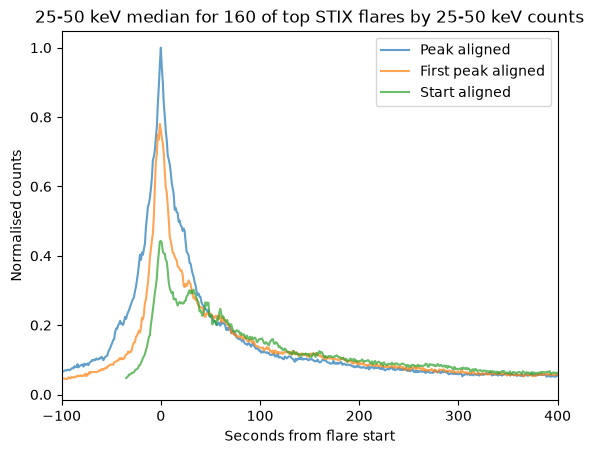

In [1044]:
start_comp = median_flare_2550.copy()
start_comp.index = start_comp.index-np.where(median_flare_2550['25.0 keV-50.0 keV']==np.max(median_flare_2550['25.0 keV-50.0 keV']))[0][0]

fp_comp = median_2550_firstpeak.copy()
fp_comp.index = fp_comp.index-np.where(median_2550_firstpeak['25.0 keV-50.0 keV']==np.max(median_2550_firstpeak['25.0 keV-50.0 keV']))[0][0]

fig, ax = plt.subplots()
ax.plot(median_2550_peaks.index, median_2550_peaks['25.0 keV-50.0 keV'], alpha = 0.7, label = 'Peak aligned')
ax.plot(median_2550_firstpeak.index, median_2550_firstpeak['25.0 keV-50.0 keV'], alpha=0.7, label = 'First peak aligned')
ax.plot(start_comp.index, start_comp['25.0 keV-50.0 keV'], alpha=0.7, label = 'Start aligned')
ax.set_xlabel('Seconds from flare start')
ax.set_ylabel('Normalised counts')
ax.legend()
ax.set_title('25-50 keV median for 160 of top STIX flares by 25-50 keV counts')
ax.set_xlim(-100, 400)

fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/sea_comparison_single_axes.png", bbox_inches='tight')

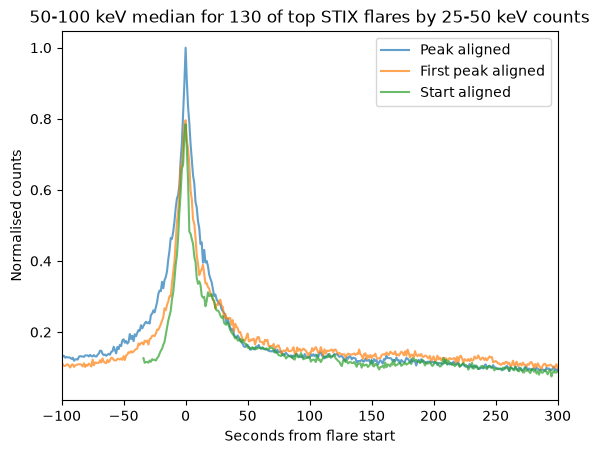

In [1042]:
start_comp_50100 = median_flare_50100.copy()
start_comp_50100.index = start_comp_50100.index-np.where(median_flare_50100['50.0 keV-100.0 keV']==np.max(median_flare_50100['50.0 keV-100.0 keV']))[0][0]

fp_comp = median_2550_firstpeak.copy()
fp_comp.index = fp_comp.index-np.where(median_2550_firstpeak['25.0 keV-50.0 keV']==np.max(median_2550_firstpeak['25.0 keV-50.0 keV']))[0][0]

fig, ax = plt.subplots()
ax.plot(median_50100_peaks.index, median_50100_peaks['50.0 keV-100.0 keV'], alpha = 0.7, label = 'Peak aligned')
ax.plot(median_50100_firstpeak.index, median_50100_firstpeak['50.0 keV-100.0 keV'], alpha=0.7, label = 'First peak aligned')
ax.plot(start_comp_50100.index, start_comp_50100['50.0 keV-100.0 keV'], alpha=0.7, label = 'Start aligned')
ax.set_xlabel('Seconds from flare start')
ax.set_ylabel('Normalised counts')
ax.legend()
ax.set_title('50-100 keV median for 130 of top STIX flares by 25-50 keV counts')
ax.set_xlim(-100, 300)

fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/sea_comparison_single_axes_50100.png", bbox_inches='tight')

In [945]:
short_flarelist = flarelist_refined.iloc[shortflare_locs]
long_flarelist = flarelist_refined.iloc[longflare_locs]

Text(0.5, 0, 'Heliographic Carrington Longitude (degrees)')

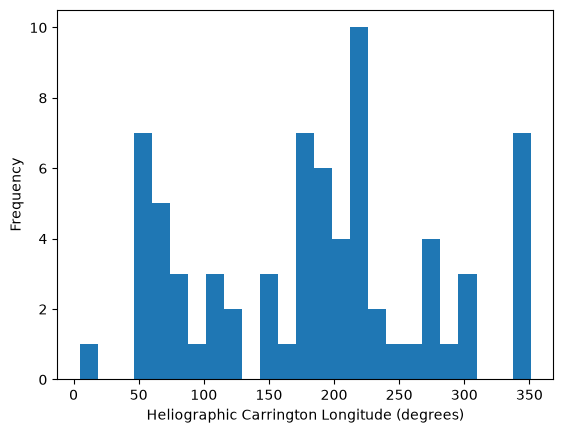

In [954]:
short_flarelist['hgc_lon'].plot(kind='hist', bins=25)
plt.xlabel('Heliographic Carrington Longitude (degrees)')

Text(0.5, 0, 'Heliographic Carrington Longitude (degrees)')

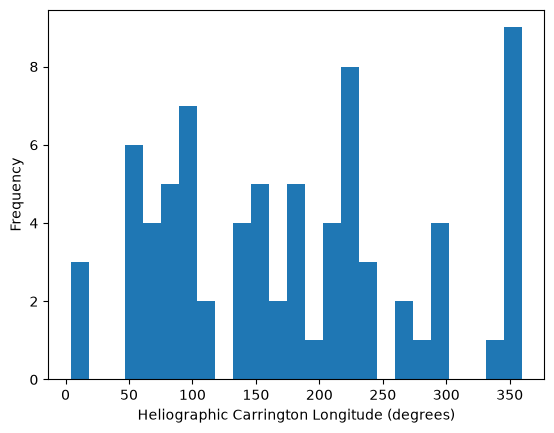

In [953]:
long_flarelist['hgc_lon'].plot(kind='hist', bins=25)
plt.xlabel('Heliographic Carrington Longitude (degrees)')

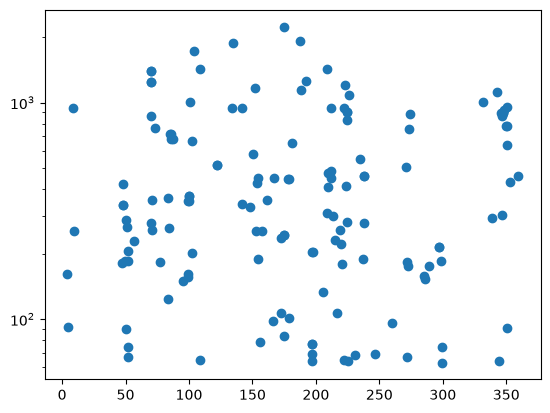

In [956]:
plt.scatter(flarelist_refined['hgc_lon'], durations)
plt.yscale('log')

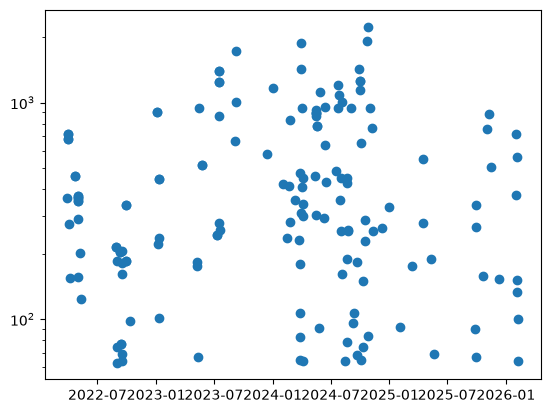

In [966]:
plt.scatter(t(peak_locs), durations_f)
plt.yscale('log')

In [1099]:
len(timeshifted_df_list_firstpeak)

164

In [1098]:
len(durations)

164

In [1109]:
i=0
for df in timeshifted_df_list_firstpeak:
    fig, ax = plt.subplots()
    ax.set_ylabel('ct/(keV s)')
    flare_time = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime
    ax.set_title(flare_time.strftime("%Y-%m-%d %H:%M"))
    if pd.notna(durations[i]):
        ax.set_xlim(-225, durations[i]+50)
    
    ax.plot(median_2550_firstpeak.index, median_2550_firstpeak['25.0 keV-50.0 keV'], label='First peak normalised SEA')
    ax.plot(df.index, df['25.0 keV-50.0 keV'], label='25-50 keV')
    
    ax.set_xlabel('Seconds from flare start')
    ax.set_ylabel('Normalised counts')
    
    ax.fill_between(median_2550_firstpeak.index, lowerlim_2550_firstpeak, upperlim_2550_firstpeak, color='lightblue', alpha=0.5)
    
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize='small')
    fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/firstpeak_norm_flare_comparison_2550/flare"+str(i)+".png", bbox_inches='tight')
    i+=1

plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_16436\2845543116.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [1110]:
i=0
for df in timeshifted_df_list_firstpeak_50100:
    fig, ax = plt.subplots()
    ax.set_ylabel('ct/(keV s)')
    flare_time = parse_time(flarelist_refined['start_UTC'].iloc[i]).datetime
    ax.set_title(flare_time.strftime("%Y-%m-%d %H:%M"))
    if pd.notna(durations_50100[i]):
        ax.set_xlim(-225, durations_50100[i]+50)
    
    ax.plot(median_50100_firstpeak.index, median_50100_firstpeak['50.0 keV-100.0 keV'], label='First peak normalised SEA')
    ax.plot(df.index, df['50.0 keV-100.0 keV'], label='50-100 keV')
    
    ax.set_xlabel('Seconds from flare start')
    ax.set_ylabel('Normalised counts')
    
    ax.fill_between(median_50100_firstpeak.index, lowerlim_50100_firstpeak, upperlim_50100_firstpeak, color='lightblue', alpha=0.5)
    
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize='small')
    fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/firstpeak_norm_flare_comparison_50100/flare"+str(i)+".png", bbox_inches='tight')
    i+=1

plt.close('all')

C:\Users\dearb\AppData\Local\Temp\ipykernel_16436\2084325739.py:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


In [1089]:
def get_fwhm(df, column):
    half_max = 0.5*np.max(df)
    
    half_max_loc = df.index[df[column]>= half_max][0]

    over_half = np.where(df[column]>half_max)
    end_point = df.index[over_half[0][-1]]

    fwhm = end_point-half_max_loc
    return fwhm

In [1090]:
get_fwhm(median_2550_firstpeak, '25.0 keV-50.0 keV')

np.int64(26)

In [1091]:
get_fwhm(median_50100_firstpeak, '50.0 keV-100.0 keV')

np.int64(18)

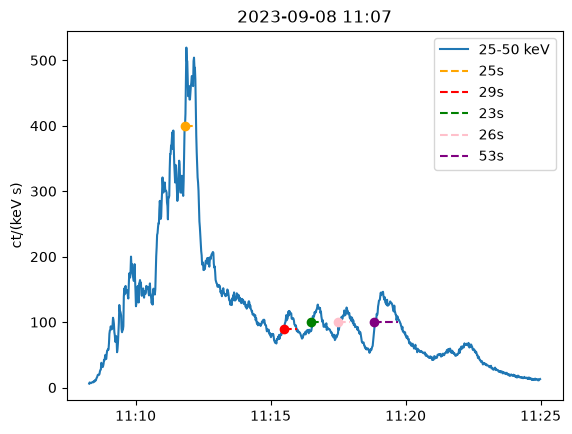

In [1194]:
flare13 = df_list_refined[13]
flare13 = flare13.truncate(starts[13], ends[13])

fig, ax = plt.subplots()
ax.set_ylabel('ct/(keV s)')
flare_time = parse_time(flarelist_refined['start_UTC'].iloc[13]).datetime
ax.set_title(flare_time.strftime("%Y-%m-%d %H:%M"))
ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))

ax.plot(flare13.index, flare13['25.0 keV-50.0 keV'], label='25-50 keV')

ax.plot(dt.datetime(2023, 9, 8, 11, 11, 50), 400, marker='o', color='orange')
ax.hlines(400, dt.datetime(2023, 9, 8, 11, 11, 50), dt.datetime(2023, 9, 8, 11, 12, 15), linestyle = 'dashed', color='orange', label = '25s')

ax.plot(dt.datetime(2023, 9, 8, 11, 15, 30), 90, marker='o', color='red')
ax.hlines(90, dt.datetime(2023, 9, 8, 11, 15, 30), dt.datetime(2023, 9, 8, 11, 15, 59), linestyle = 'dashed', color='red', label = '29s')

ax.plot(dt.datetime(2023, 9, 8, 11, 16, 30), 100, marker='o', color='green')
ax.hlines(100, dt.datetime(2023, 9, 8, 11, 16, 30), dt.datetime(2023, 9, 8, 11, 16, 53), linestyle = 'dashed', color='green', label = '23s')

ax.plot(dt.datetime(2023, 9, 8, 11, 17, 30), 100, marker='o', color='pink')
ax.hlines(100, dt.datetime(2023, 9, 8, 11, 17, 30), dt.datetime(2023, 9, 8, 11, 17, 56), linestyle = 'dashed', color='pink', label = '26s')

ax.plot(dt.datetime(2023, 9, 8, 11, 18, 50), 100, marker='o', color='purple')
ax.hlines(100, dt.datetime(2023, 9, 8, 11, 18, 50), dt.datetime(2023, 9, 8, 11, 19, 43), linestyle = 'dashed', color='purple', label = '53s')


ax.legend()

fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/fwhm_ex.png", bbox_inches='tight')

In [1169]:
df=flare13
column='25.0 keV-50.0 keV'

half_max = 400

half_max_loc = df.index[df[column]>= half_max][0]

less_half = np.where((df[column]<half_max)&(t(df.index)>half_max_loc))
end_point = df.index[less_half[0][0]]

fwhm = end_point-half_max_loc
fwhm.total_seconds()

25.0

In [1170]:
half_max = 90

half_max_loc = df.index[(df[column]>= half_max)&(t(df.index)>dt.datetime(2023, 9, 8, 11, 15))][0]

less_half = np.where((df[column]<half_max)&(t(df.index)>half_max_loc))
end_point = df.index[less_half[0][0]]

fwhm = end_point-half_max_loc
fwhm.total_seconds()

29.0

In [1171]:
half_max=100
half_max_loc = df.index[(df[column]>= half_max)&(t(df.index)>end_point)][0]

less_half = np.where((df[column]<half_max)&(t(df.index)>half_max_loc))
end_point = df.index[less_half[0][0]]

fwhm = end_point-half_max_loc
fwhm.total_seconds()

23.0

In [1172]:
half_max = 100

half_max_loc = df.index[(df[column]>= half_max)&(t(df.index)>end_point)][0]

less_half = np.where((df[column]<half_max)&(t(df.index)>half_max_loc))
end_point = df.index[less_half[0][0]]

fwhm = end_point-half_max_loc
fwhm.total_seconds()

26.0

In [1174]:
half_max = 100

half_max_loc = df.index[(df[column]>= half_max)&(t(df.index)>dt.datetime(2023, 9, 8, 11, 18, 30))][0]

less_half = np.where((df[column]<half_max)&(t(df.index)>half_max_loc))
end_point = df.index[less_half[0][0]]

fwhm = end_point-half_max_loc
fwhm.total_seconds()

53.0

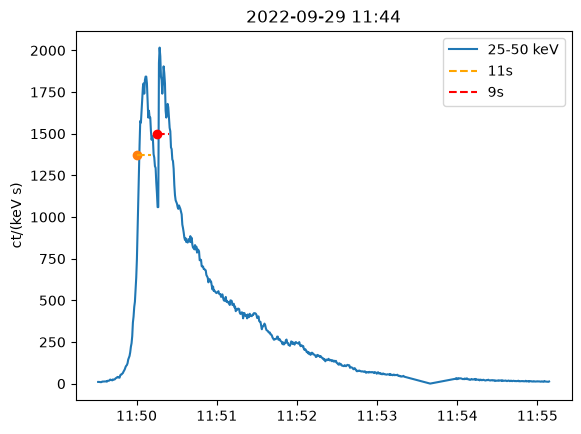

In [1197]:
flare1 = df_list_refined[1]
flare1 = flare1.truncate(starts[1], ends[1])

fig, ax = plt.subplots()
ax.set_ylabel('ct/(keV s)')
flare_time = parse_time(flarelist_refined['start_UTC'].iloc[1]).datetime
ax.set_title(flare_time.strftime("%Y-%m-%d %H:%M"))
ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))

ax.plot(t(flare1.index), flare1['25.0 keV-50.0 keV'], label = '25-50 keV')

ax.plot(dt.datetime(2022, 9, 29, 11, 50), 1375, marker='o')
ax.hlines(1375, dt.datetime(2022, 9, 29, 11, 50), dt.datetime(2022, 9, 29, 11, 50, 11), linestyle = 'dashed', color='orange', label = '11s')

ax.plot(dt.datetime(2022, 9, 29, 11, 50, 15), 1500, marker='o', color='red')
ax.hlines(1500, dt.datetime(2022, 9, 29, 11, 50, 15), dt.datetime(2022, 9, 29, 11, 50, 24), linestyle = 'dashed', color='red', label = '9s')

ax.legend()

fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/fwhm_ex3.png", bbox_inches='tight')

In [1136]:
df=flare1
column='25.0 keV-50.0 keV'

half_max = 1375

half_max_loc = df.index[df[column]>= half_max][0]

less_half = np.where((df[column]<half_max)&(t(df.index)>half_max_loc))
end_point = df.index[less_half[0][0]]

fwhm = end_point-half_max_loc
fwhm.total_seconds()

11.0

In [1144]:
df=flare1
column='25.0 keV-50.0 keV'

half_max = 1500

half_max_loc = df.index[(df[column]>= half_max)&(t(df.index)>end_point)][0]

less_half = np.where((df[column]<half_max)&(t(df.index)>half_max_loc))
end_point = df.index[less_half[0][0]]

fwhm = end_point-half_max_loc
fwhm.total_seconds()

9.0

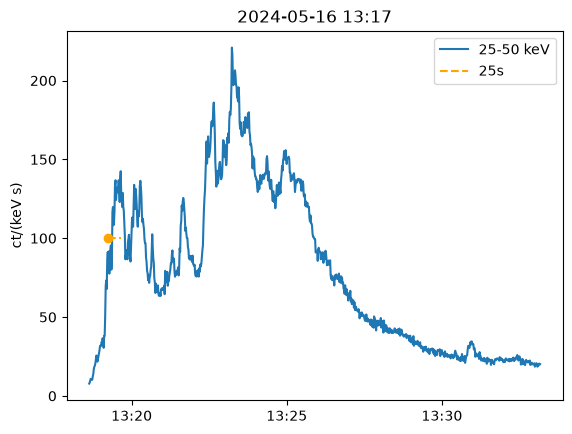

In [1195]:
flare35 = df_list_refined[35]
flare35 = flare35.truncate(starts[35], ends[35])

fig, ax = plt.subplots()
ax.set_ylabel('ct/(keV s)')
flare_time = parse_time(flarelist_refined['start_UTC'].iloc[35]).datetime
ax.set_title(flare_time.strftime("%Y-%m-%d %H:%M"))
ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))

ax.plot(flare35.index, flare35['25.0 keV-50.0 keV'], label='25-50 keV')

ax.plot(dt.datetime(2024, 5, 16, 13, 19, 15), 100, marker='o', color='orange')
ax.hlines(100, dt.datetime(2024, 5, 16, 13, 19, 15), dt.datetime(2024, 5, 16, 13, 19, 40), linestyle = 'dashed', color='orange', label = '25s')

ax.legend()

fig.savefig("C:/Users/dearb/Documents/DIAS/solar-orbiter-flare-statistics/figures/week_10/fwhm_ex2.png", bbox_inches='tight')

In [1184]:
df=flare35
column='25.0 keV-50.0 keV'

half_max = 100

half_max_loc = df.index[df[column]>= half_max][0]

less_half = np.where((df[column]<half_max)&(t(df.index)>half_max_loc))
end_point = df.index[less_half[0][0]]

fwhm = end_point-half_max_loc
fwhm.total_seconds()

25.0

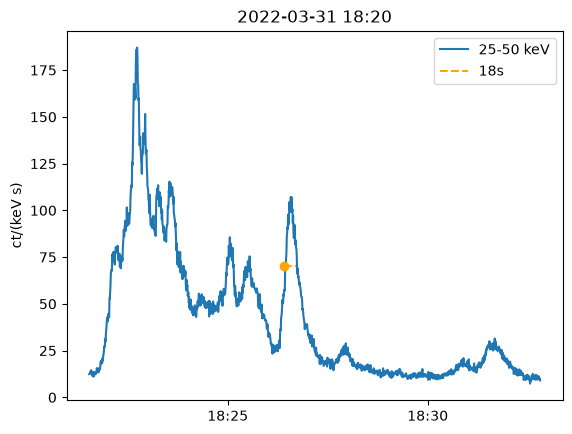

In [1193]:
flare45 = df_list_refined[45]
flare45 = flare45.truncate(starts[45], ends[45])

fig, ax = plt.subplots()
ax.set_ylabel('ct/(keV s)')
flare_time = parse_time(flarelist_refined['start_UTC'].iloc[45]).datetime
ax.set_title(flare_time.strftime("%Y-%m-%d %H:%M"))
ax.xaxis.set_major_formatter(dates.DateFormatter("%H:%M"))

ax.plot(flare45.index, flare45['25.0 keV-50.0 keV'], label='25-50 keV')

ax.plot(dt.datetime(2022, 3, 31, 18, 26, 25), 70, marker='o', color='orange')
ax.hlines(70, dt.datetime(2022, 3, 31, 18, 26, 25), dt.datetime(2022, 3, 31, 18, 26, 43), linestyle = 'dashed', color='orange', label = '18s')

ax.legend()

In [1191]:
df=flare45
column='25.0 keV-50.0 keV'

half_max = 70

half_max_loc = df.index[(df[column]>= half_max)&(t(df.index)>dt.datetime(2022, 3, 31, 18, 26))][0]

less_half = np.where((df[column]<half_max)&(t(df.index)>half_max_loc))
end_point = df.index[less_half[0][0]]

fwhm = end_point-half_max_loc
fwhm.total_seconds()

17.5